<a href="https://colab.research.google.com/github/prameela-rani-patnaik/KNN/blob/main/M4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
df=pd.read_csv("overlapping_dataset_200.csv")

In [ ]:
df.shape

(200, 3)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       200 non-null    float64
 1   y       200 non-null    float64
 2   Region  200 non-null    object 
dtypes: float64(2), object(1)
memory usage: 4.8+ KB


In [ ]:
df.isnull()

,x,y,Region
0,False,False,False
1,False,False,False
2,False,False,False
3,False,False,False
4,False,False,False
...,...,...,...
195,False,False,False
196,False,False,False
197,False,False,False
198,False,False,False


In [ ]:
x = df[['x', 'y']]      # Input features
y = df['Region']        # Target variable

In [ ]:
# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

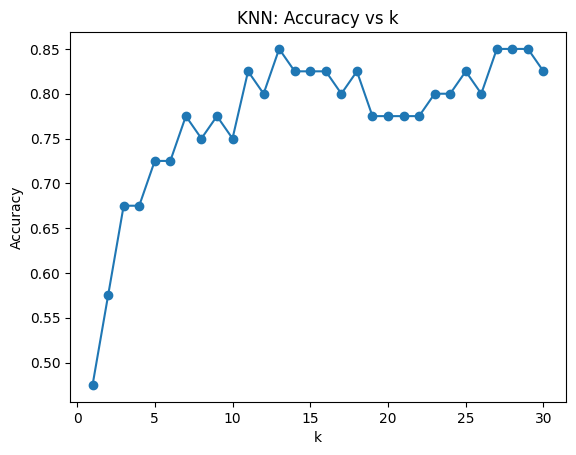

In [ ]:
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

k_values = range(1, 31)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled, y_train)

    y_pred = model.predict(X_test_scaled)
    accuracies.append(accuracy_score(y_test, y_pred))

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN: Accuracy vs k")
plt.show()

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

model = KNeighborsClassifier(n_neighbors=15)

model.fit(X_train_scaled, y_train)


KNeighborsClassifier(n_neighbors=15)

In [ ]:
y_pred = model.predict(X_test_scaled)

# Accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)


Accuracy: 0.825


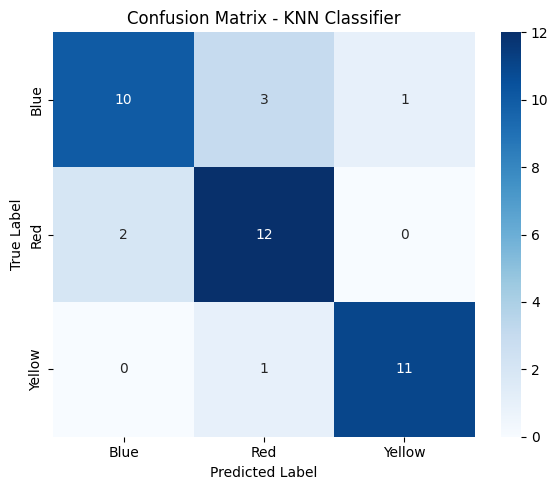


Classification Report:
              precision    recall  f1-score   support

        Blue       0.83      0.71      0.77        14
         Red       0.75      0.86      0.80        14
      Yellow       0.92      0.92      0.92        12

    accuracy                           0.82        40
   macro avg       0.83      0.83      0.83        40
weighted avg       0.83      0.82      0.82        40



In [88]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Class labels
labels = model.classes_

# Plot
plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - KNN Classifier")
plt.tight_layout()
plt.show()

# Classification Report
from sklearn.metrics import classification_report

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

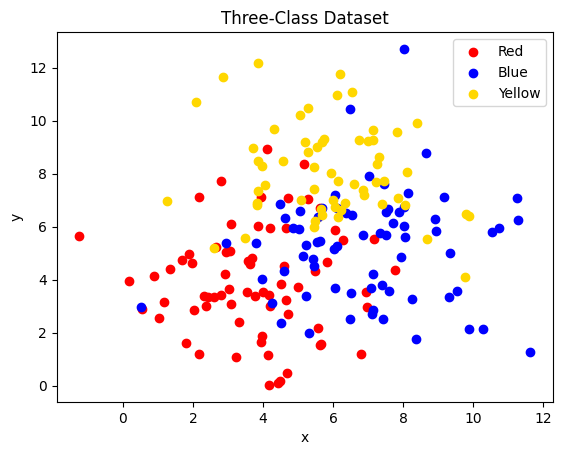

In [ ]:
import matplotlib.pyplot as plt

colors = {
    'Red': 'red',
    'Blue': 'blue',
    'Yellow': 'gold'
}

for region in df['Region'].unique():
    subset = df[df['Region'] == region]
    plt.scatter(
        subset['x'],
        subset['y'],
        c=colors[region],
        label=region
    )

plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.title("Three-Class Dataset")
plt.show()

In [ ]:
new_data = pd.DataFrame({
    'x': [5],
    'y': [2]
})

new_data_scaled = scaler.transform(new_data)

prediction = model.predict(new_data_scaled)
probabilities = model.predict_proba(new_data_scaled)

print("Predicted Region:", prediction[0])
print("Probabilities:", probabilities[0])

Predicted Region: Red
Probabilities: [0.33333333 0.66666667 0.        ]
